In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.shape

(768, 9)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
df["Outcome"].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [8]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

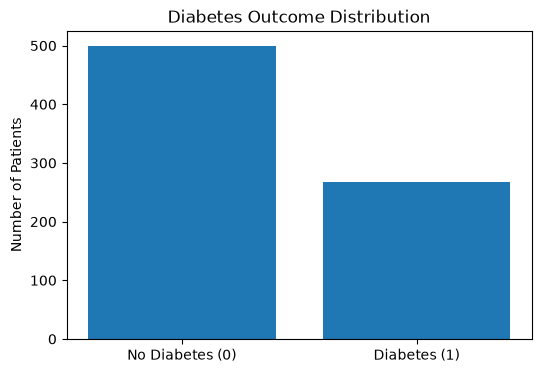

In [9]:
outcome_counts = df["Outcome"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Diabetes (0)", "Diabetes (1)"],
    outcome_counts.values
)

plt.title("Diabetes Outcome Distribution")
plt.ylabel("Number of Patients")
plt.show()

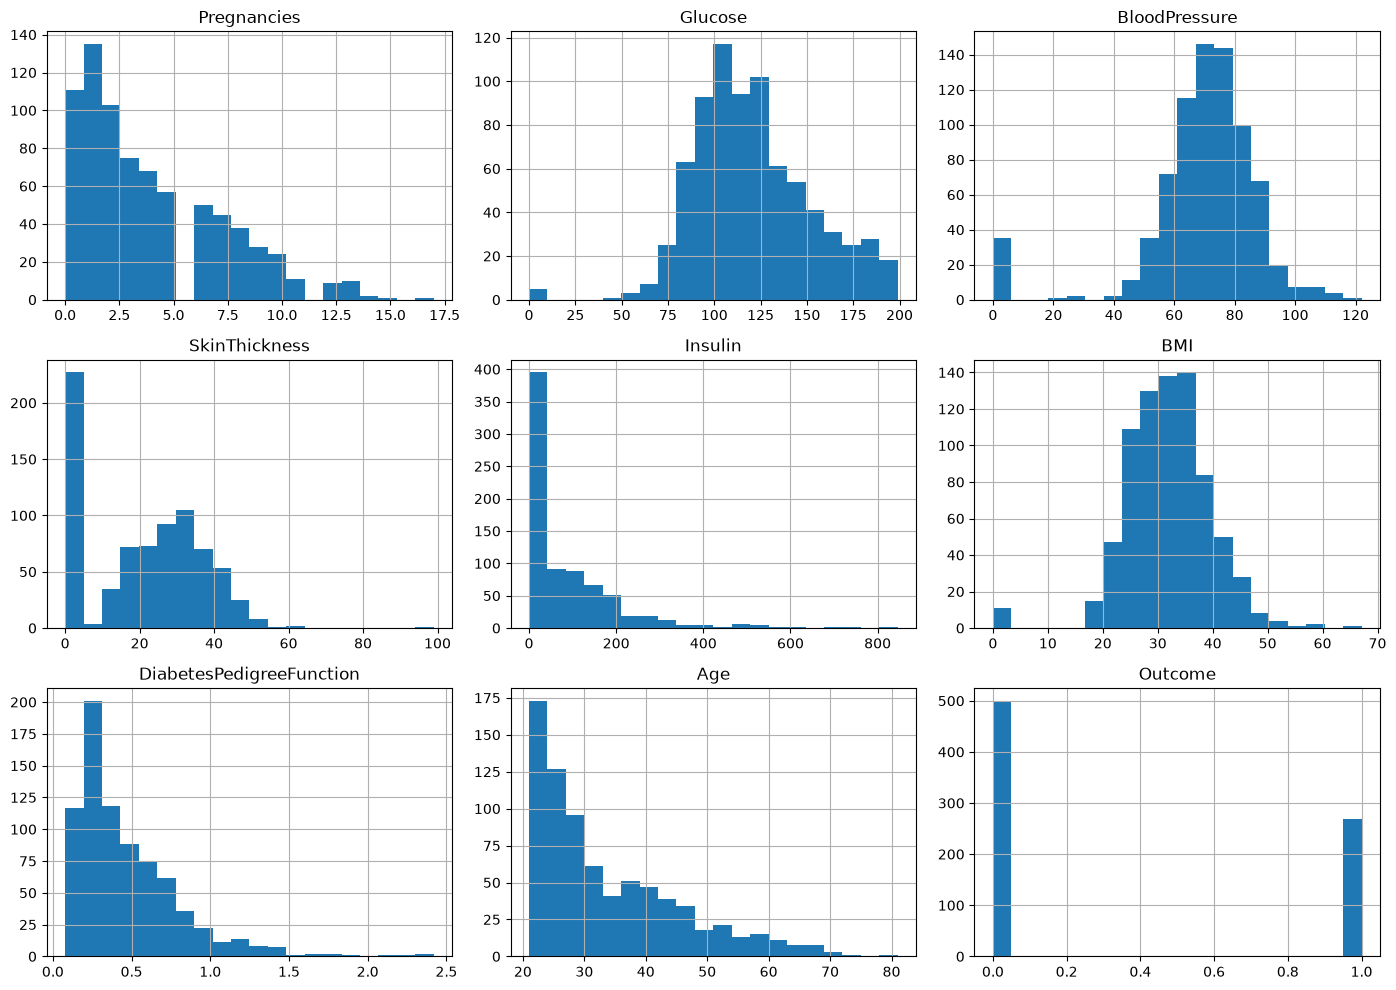

In [10]:
df.hist(
    figsize=(14, 10),
    bins=20
)

plt.tight_layout()
plt.show()

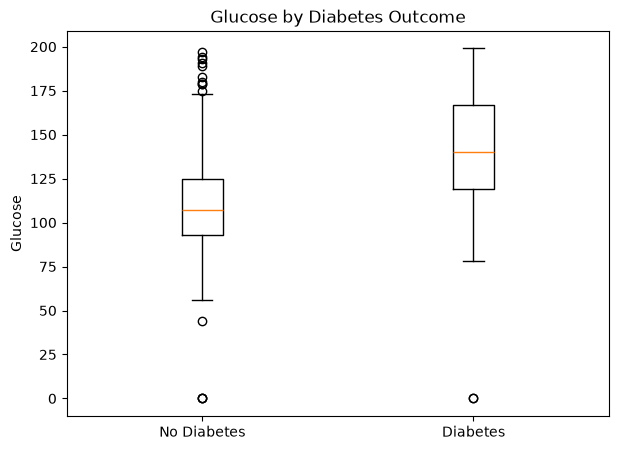

In [12]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df[df["Outcome"] == 0]["Glucose"],
        df[df["Outcome"] == 1]["Glucose"]
    ],
    tick_labels=["No Diabetes", "Diabetes"]
)

plt.title("Glucose by Diabetes Outcome")
plt.ylabel("Glucose")
plt.show()

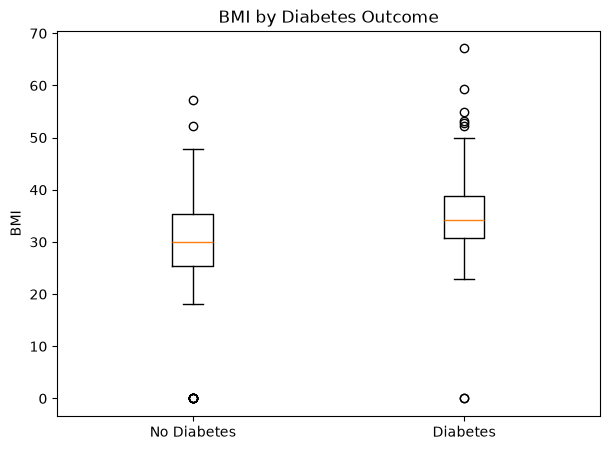

In [13]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df[df["Outcome"] == 0]["BMI"],
        df[df["Outcome"] == 1]["BMI"]
    ],
    tick_labels=["No Diabetes", "Diabetes"]
)

plt.title("BMI by Diabetes Outcome")
plt.ylabel("BMI")
plt.show()

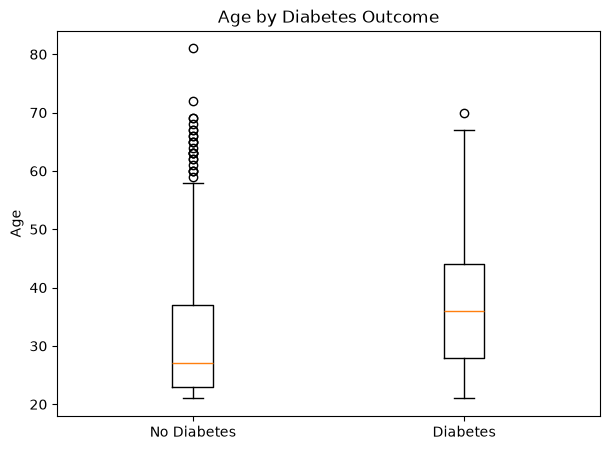

In [14]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df[df["Outcome"] == 0]["Age"],
        df[df["Outcome"] == 1]["Age"]
    ],
    tick_labels=["No Diabetes", "Diabetes"]
)

plt.title("Age by Diabetes Outcome")
plt.ylabel("Age")
plt.show()

In [15]:
df.corr()["Outcome"].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

In [16]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in zero_columns:
    print(f"\n{col}: {df[col].eq(0).sum()} zeros")


Glucose: 5 zeros

BloodPressure: 35 zeros

SkinThickness: 227 zeros

Insulin: 374 zeros

BMI: 11 zeros


In [17]:
for col in zero_columns:
    print(f"\n--- {col} ---")
    
    zero_mask = df[col] == 0
    
    print("Outcome distribution when zero:")
    print(df.loc[zero_mask, "Outcome"].value_counts(normalize=True) * 100)
    
    print("Outcome distribution when non-zero:")
    print(df.loc[~zero_mask, "Outcome"].value_counts(normalize=True) * 100)


--- Glucose ---
Outcome distribution when zero:
Outcome
0    60.0
1    40.0
Name: proportion, dtype: float64
Outcome distribution when non-zero:
Outcome
0    65.137615
1    34.862385
Name: proportion, dtype: float64

--- BloodPressure ---
Outcome distribution when zero:
Outcome
0    54.285714
1    45.714286
Name: proportion, dtype: float64
Outcome distribution when non-zero:
Outcome
0    65.620737
1    34.379263
Name: proportion, dtype: float64

--- SkinThickness ---
Outcome distribution when zero:
Outcome
0    61.23348
1    38.76652
Name: proportion, dtype: float64
Outcome distribution when non-zero:
Outcome
0    66.728281
1    33.271719
Name: proportion, dtype: float64

--- Insulin ---
Outcome distribution when zero:
Outcome
0    63.101604
1    36.898396
Name: proportion, dtype: float64
Outcome distribution when non-zero:
Outcome
0    67.005076
1    32.994924
Name: proportion, dtype: float64

--- BMI ---
Outcome distribution when zero:
Outcome
0    81.818182
1    18.181818
Name: pro

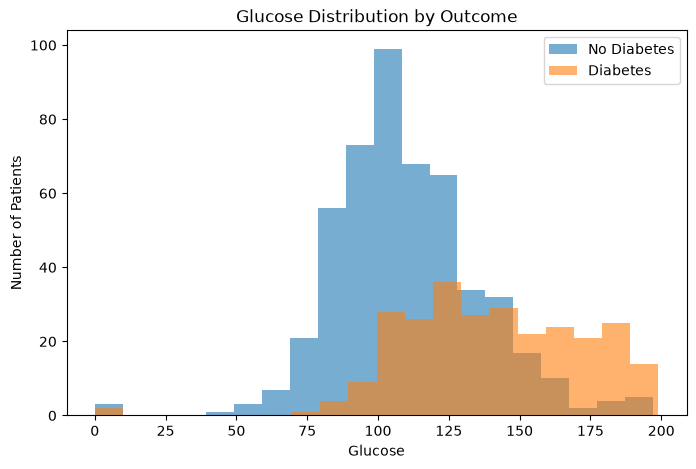

In [18]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Outcome"] == 0]["Glucose"],
    bins=20,
    alpha=0.6,
    label="No Diabetes"
)

plt.hist(
    df[df["Outcome"] == 1]["Glucose"],
    bins=20,
    alpha=0.6,
    label="Diabetes"
)

plt.xlabel("Glucose")
plt.ylabel("Number of Patients")
plt.title("Glucose Distribution by Outcome")
plt.legend()
plt.show()

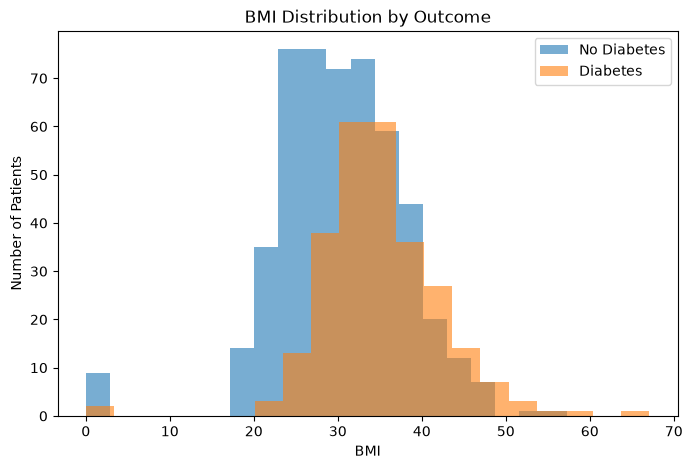

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df["Outcome"] == 0]["BMI"],
    bins=20,
    alpha=0.6,
    label="No Diabetes"
)

plt.hist(
    df[df["Outcome"] == 1]["BMI"],
    bins=20,
    alpha=0.6,
    label="Diabetes"
)

plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.title("BMI Distribution by Outcome")
plt.legend()
plt.show()

In [20]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

for col in zero_columns:
    print(f"\n{col}: {df[col].eq(0).sum()} zeros")


Glucose: 5 zeros

BloodPressure: 35 zeros

SkinThickness: 227 zeros

Insulin: 374 zeros

BMI: 11 zeros


In [21]:
for col in zero_columns:
    print(f"\n--- {col} ---")
    
    zero_mask = df[col] == 0
    
    print("Outcome distribution when zero:")
    print(df.loc[zero_mask, "Outcome"].value_counts(normalize=True) * 100)
    
    print("Outcome distribution when non-zero:")
    print(df.loc[~zero_mask, "Outcome"].value_counts(normalize=True) * 100)


--- Glucose ---
Outcome distribution when zero:
Outcome
0    60.0
1    40.0
Name: proportion, dtype: float64
Outcome distribution when non-zero:
Outcome
0    65.137615
1    34.862385
Name: proportion, dtype: float64

--- BloodPressure ---
Outcome distribution when zero:
Outcome
0    54.285714
1    45.714286
Name: proportion, dtype: float64
Outcome distribution when non-zero:
Outcome
0    65.620737
1    34.379263
Name: proportion, dtype: float64

--- SkinThickness ---
Outcome distribution when zero:
Outcome
0    61.23348
1    38.76652
Name: proportion, dtype: float64
Outcome distribution when non-zero:
Outcome
0    66.728281
1    33.271719
Name: proportion, dtype: float64

--- Insulin ---
Outcome distribution when zero:
Outcome
0    63.101604
1    36.898396
Name: proportion, dtype: float64
Outcome distribution when non-zero:
Outcome
0    67.005076
1    32.994924
Name: proportion, dtype: float64

--- BMI ---
Outcome distribution when zero:
Outcome
0    81.818182
1    18.181818
Name: pro

In [22]:
zero_summary = []

for col in zero_columns:
    zero_mask = df[col] == 0

    zero_summary.append({
        "Feature": col,
        "Zero Count": int(zero_mask.sum()),
        "Zero %": round(zero_mask.mean() * 100, 2),
        "Diabetes % when Zero": round(
            df.loc[zero_mask, "Outcome"].mean() * 100, 2
        ),
        "Diabetes % when Non-Zero": round(
            df.loc[~zero_mask, "Outcome"].mean() * 100, 2
        )
    })

pd.DataFrame(zero_summary)

,Feature,Zero Count,Zero %,Diabetes % when Zero,Diabetes % when Non-Zero
0,Glucose,5,0.65,40.00,34.86
1,BloodPressure,35,4.56,45.71,34.38
2,SkinThickness,227,29.56,38.77,33.27
3,Insulin,374,48.70,36.90,32.99
4,BMI,11,1.43,18.18,35.14


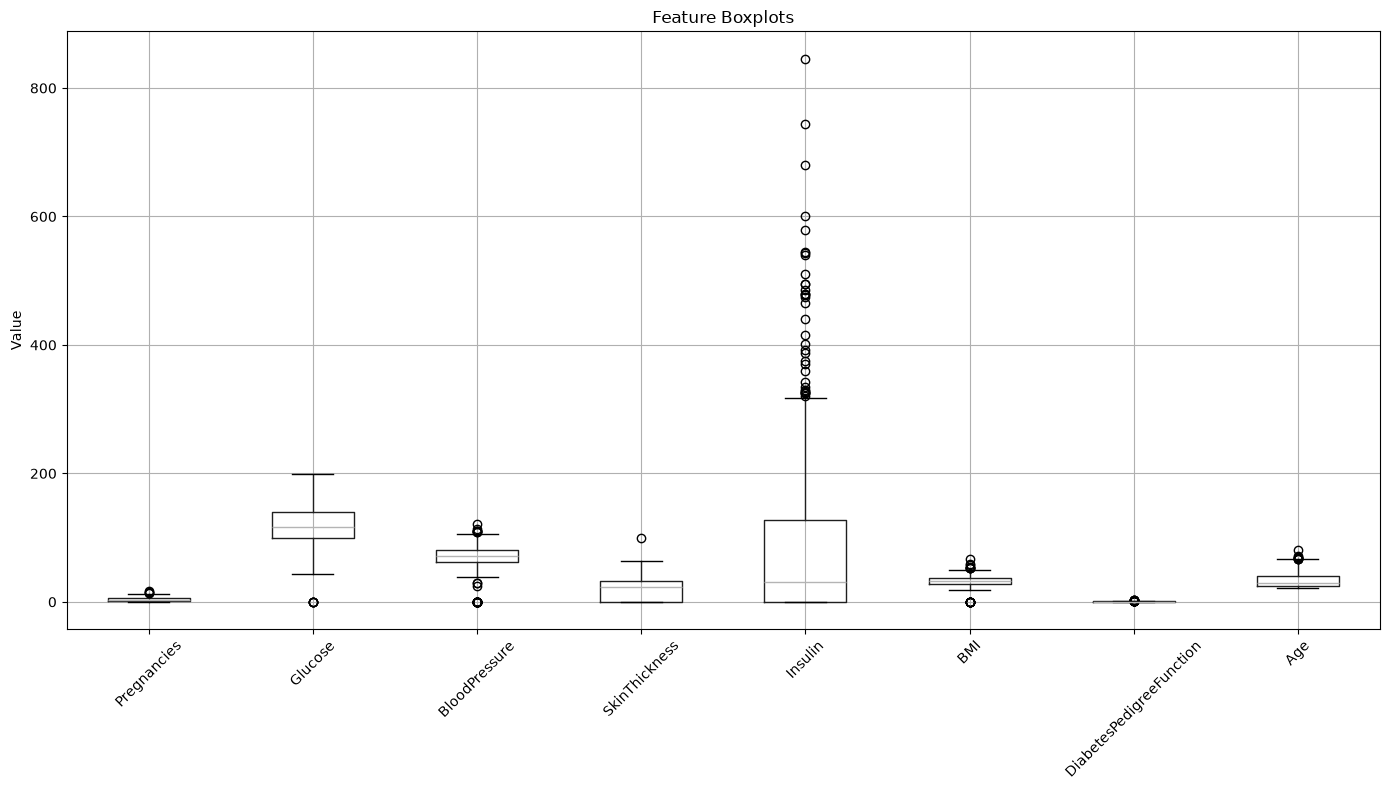

In [23]:
plt.figure(figsize=(14, 8))

df.boxplot(
    column=[
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ]
)

plt.xticks(rotation=45)
plt.title("Feature Boxplots")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [24]:
df.drop(columns="Outcome").describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns="Outcome")
y = df["Outcome"]

zero_as_missing = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X = X.copy()

for col in zero_as_missing:
    X[col] = X[col].replace(0, np.nan)

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33


In [26]:
X.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 614
Testing samples: 154

Training target distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing target distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [28]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account fo

In [29]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessing", numeric_pipeline),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be i

In [30]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions:")
print(y_pred[:10])

print("\nProbabilities:")
print(y_prob[:10])

Predictions:
[1 0 0 0 0 0 0 1 0 1]

Probabilities:
[0.60969998 0.11829145 0.29342565 0.25080052 0.03352696 0.16847753
 0.48806448 0.92366487 0.0814217  0.83859286]


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.7077922077922078
Precision: 0.6
Recall   : 0.5
F1 Score : 0.5454545454545454
ROC-AUC  : 0.812962962962963

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



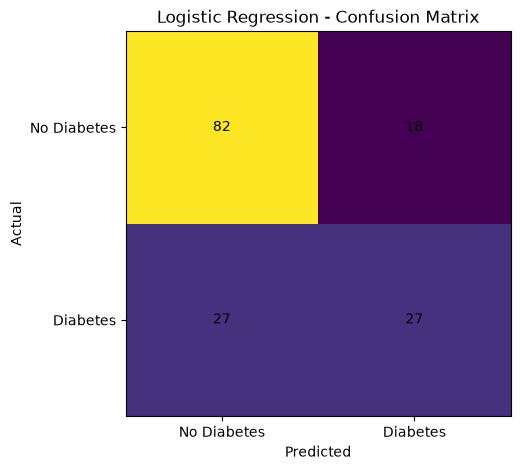

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.yticks([0, 1], ["No Diabetes", "Diabetes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessing", numeric_pipeline),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be i

In [34]:
rf_pred = random_forest_model.predict(X_test)
rf_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [35]:
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy : 0.7402597402597403
Precision: 0.6590909090909091
Recall   : 0.5370370370370371
F1 Score : 0.5918367346938775
ROC-AUC  : 0.8160185185185185

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81       100
           1       0.66      0.54      0.59        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154



In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline([
    ("preprocessing", numeric_pipeline),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gradient_boosting_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pregnancies','Glucose','BloodPressure',...,'BMI', 'DiabetesPedigreeFunction','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be i

In [37]:
gb_pred = gradient_boosting_model.predict(X_test)
gb_prob = gradient_boosting_model.predict_proba(X_test)[:, 1]

In [38]:
print("Accuracy :", accuracy_score(y_test, gb_pred))
print("Precision:", precision_score(y_test, gb_pred))
print("Recall   :", recall_score(y_test, gb_pred))
print("F1 Score :", f1_score(y_test, gb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, gb_prob))

print("\nClassification Report:")
print(classification_report(y_test, gb_pred))

Accuracy : 0.7532467532467533
Precision: 0.6818181818181818
Recall   : 0.5555555555555556
F1 Score : 0.6122448979591837
ROC-AUC  : 0.8301851851851852

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       100
           1       0.68      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



In [39]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.7078,0.6000,0.5000,0.5455,0.8130
1,Random Forest,0.7403,0.6591,0.5370,0.5918,0.8160
2,Gradient Boosting,0.7532,0.6818,0.5556,0.6122,0.8302


In [40]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ],
    n_jobs=-1
)

cv_summary = {
    "Accuracy": cv_results["test_accuracy"].mean(),
    "Precision": cv_results["test_precision"].mean(),
    "Recall": cv_results["test_recall"].mean(),
    "F1": cv_results["test_f1"].mean(),
    "ROC-AUC": cv_results["test_roc_auc"].mean()
}

pd.Series(cv_summary).round(4)

Accuracy     0.7557
Precision    0.6721
Recall       0.5981
F1           0.6308
ROC-AUC      0.8206
dtype: float64

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [1, 2, 3],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=gradient_boosting_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [1, 2, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to

In [42]:
print("Best ROC-AUC:", grid_search.best_score_)
print("\nBest parameters:")
print(grid_search.best_params_)

Best ROC-AUC: 0.835483803986711

Best parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 1, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [43]:
best_model = grid_search.best_estimator_

tuned_pred = best_model.predict(X_test)
tuned_prob = best_model.predict_proba(X_test)[:, 1]

print("Test Accuracy :", accuracy_score(y_test, tuned_pred))
print("Test Precision:", precision_score(y_test, tuned_pred))
print("Test Recall   :", recall_score(y_test, tuned_pred))
print("Test F1       :", f1_score(y_test, tuned_pred))
print("Test ROC-AUC  :", roc_auc_score(y_test, tuned_prob))

Test Accuracy : 0.7532467532467533
Test Precision: 0.7
Test Recall   : 0.5185185185185185
Test F1       : 0.5957446808510638
Test ROC-AUC  : 0.8186111111111111


In [44]:
baseline_cv = cross_validate(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

tuned_cv = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"],
    n_jobs=-1
)

cv_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Baseline Gradient Boosting": [
        baseline_cv["test_accuracy"].mean(),
        baseline_cv["test_precision"].mean(),
        baseline_cv["test_recall"].mean(),
        baseline_cv["test_f1"].mean(),
        baseline_cv["test_roc_auc"].mean()
    ],
    "Tuned Gradient Boosting": [
        tuned_cv["test_accuracy"].mean(),
        tuned_cv["test_precision"].mean(),
        tuned_cv["test_recall"].mean(),
        tuned_cv["test_f1"].mean(),
        tuned_cv["test_roc_auc"].mean()
    ]
})

cv_comparison.round(4)

,Metric,Baseline Gradient Boosting,Tuned Gradient Boosting
0,Accuracy,0.7557,0.7768
1,Precision,0.6721,0.7559
2,Recall,0.5981,0.5422
3,F1,0.6308,0.6283
4,ROC-AUC,0.8206,0.8355


In [45]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    tuned_prob
)

threshold_results = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision[:-1],
    "Recall": recall[:-1]
})

threshold_results[
    threshold_results["Threshold"].between(0.30, 0.70)
].head(20)

,Threshold,Precision,Recall
76,0.300451,0.608108,0.833333
77,0.301279,0.602740,0.814815
78,0.309864,0.597222,0.796296
79,0.316015,0.605634,0.796296
80,0.322574,0.594203,0.759259
81,0.325991,0.588235,0.740741
82,0.335358,0.597015,0.740741
83,0.337228,0.606061,0.740741
84,0.356800,0.625000,0.740741
85,0.358513,0.634921,0.740741


In [46]:
threshold_results["F1"] = (
    2 * threshold_results["Precision"] * threshold_results["Recall"]
    / (
        threshold_results["Precision"]
        + threshold_results["Recall"]
        + 1e-12
    )
)

best_threshold_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best_threshold_row

Threshold    0.300451
Precision    0.608108
Recall       0.833333
F1           0.703125
Name: 76, dtype: float64

In [47]:
from sklearn.model_selection import cross_val_predict

oof_prob = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print("Generated out-of-fold probabilities:", len(oof_prob))

Generated out-of-fold probabilities: 614


In [48]:
precision_oof, recall_oof, thresholds_oof = precision_recall_curve(
    y_train,
    oof_prob
)

oof_thresholds = pd.DataFrame({
    "Threshold": thresholds_oof,
    "Precision": precision_oof[:-1],
    "Recall": recall_oof[:-1]
})

oof_thresholds["F1"] = (
    2 * oof_thresholds["Precision"] * oof_thresholds["Recall"]
    / (
        oof_thresholds["Precision"]
        + oof_thresholds["Recall"]
        + 1e-12
    )
)

best_oof_threshold = oof_thresholds.loc[
    oof_thresholds["F1"].idxmax()
]

best_oof_threshold

Threshold    0.336757
Precision    0.635659
Recall       0.766355
F1           0.694915
Name: 334, dtype: float64

In [49]:
final_threshold = float(best_oof_threshold["Threshold"])

final_test_pred = (
    tuned_prob >= final_threshold
).astype(int)

In [50]:
print("Final threshold:", final_threshold)

print("Accuracy :", accuracy_score(y_test, final_test_pred))
print("Precision:", precision_score(y_test, final_test_pred))
print("Recall   :", recall_score(y_test, final_test_pred))
print("F1 Score :", f1_score(y_test, final_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, tuned_prob))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_test_pred
    )
)

Final threshold: 0.33675703676714175
Accuracy : 0.7402597402597403
Precision: 0.6060606060606061
Recall   : 0.7407407407407407
F1 Score : 0.6666666666666666
ROC-AUC  : 0.8186111111111111

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       100
           1       0.61      0.74      0.67        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.76      0.74      0.74       154



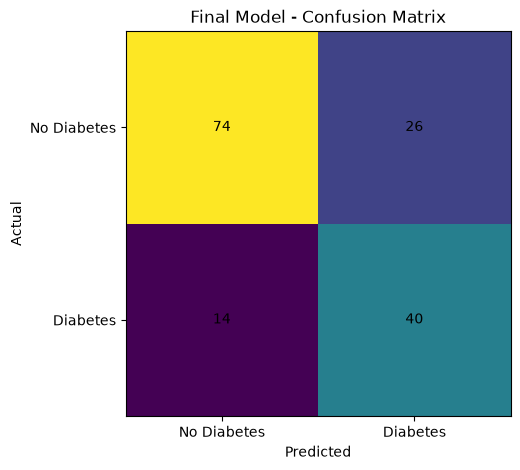

In [51]:
cm = confusion_matrix(y_test, final_test_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Final Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.yticks([0, 1], ["No Diabetes", "Diabetes"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [52]:
# Find thresholds with at least 75% recall
recall_target = 0.75

eligible = oof_thresholds[
    oof_thresholds["Recall"] >= recall_target
].copy()

best_recall_threshold = eligible.loc[
    eligible["Precision"].idxmax()
]

best_recall_threshold

Threshold    0.342977
Precision    0.636364
Recall       0.752336
F1           0.689507
Name: 338, dtype: float64

In [53]:
screening_threshold = float(
    best_recall_threshold["Threshold"]
)

screening_test_pred = (
    tuned_prob >= screening_threshold
).astype(int)

print("Screening threshold:", screening_threshold)
print("Accuracy :", accuracy_score(y_test, screening_test_pred))
print("Precision:", precision_score(y_test, screening_test_pred))
print("Recall   :", recall_score(y_test, screening_test_pred))
print("F1 Score :", f1_score(y_test, screening_test_pred))
print("ROC-AUC  :", roc_auc_score(y_test, tuned_prob))

Screening threshold: 0.34297734907337496
Accuracy : 0.7532467532467533
Precision: 0.625
Recall   : 0.7407407407407407
F1 Score : 0.6779661016949152
ROC-AUC  : 0.8186111111111111
